# Customer Churn Prediction (Telco)

Predict which telecom customers are likely to cancel, explain **why** for each customer, and choose the decision threshold from business cost instead of accuracy.

**Pipeline:** data cleaning → EDA → feature encoding → logistic regression baseline → XGBoost with class-imbalance handling → cost-based threshold tuning → SHAP explanations → saved model for the Streamlit app (`app.py`).

**Data:** [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) (IBM sample dataset, 7,043 customers, 21 columns). Download `WA_Fn-UseC_-Telco-Customer-Churn.csv` into the `data/` folder before running this notebook.

## 1. The problem

**Churn** means a customer cancels their service. Keeping an existing customer is much cheaper than winning a new one, so the business wants to find likely churners *before* they leave and offer them something to stay.

The model gives every customer a churn **risk score**, and the retention team contacts customers above a chosen threshold. The two possible mistakes have very different costs:

| Mistake | What happens | Cost |
|---|---|---|
| False negative | A churner is predicted "safe" and leaves | Lost customer (expensive) |
| False positive | A loyal customer receives an offer they didn't need | Wasted offer (cheap) |

Because a missed churner costs far more than a wasted offer, **recall on the churn class** is the main metric, not accuracy. This is a supervised binary classification problem.

## 2. Load and clean the data

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

data = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
data.shape

(7043, 21)

In [2]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

`TotalCharges` is stored as **text**, even though it holds amounts of money. Pandas turns a whole column into text if even one value can't be read as a number. The null count doesn't reveal the problem: the bad values are blank strings (`" "`), which count as "non-null".

In [4]:
blanks = data["TotalCharges"] == " "
print("Blank TotalCharges:", blanks.sum())
data.loc[blanks, ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

Blank TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


All 11 blank rows have `tenure == 0`: brand-new customers who haven't been billed yet, so their total charges really are 0. Filling with 0 uses the true value. Dropping them would lose real customers, and filling with an average would invent data.

In [5]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce").fillna(0)
data["TotalCharges"].dtype, data["TotalCharges"].isna().sum()

(dtype('float64'), np.int64(0))

## 3. Exploratory analysis

Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


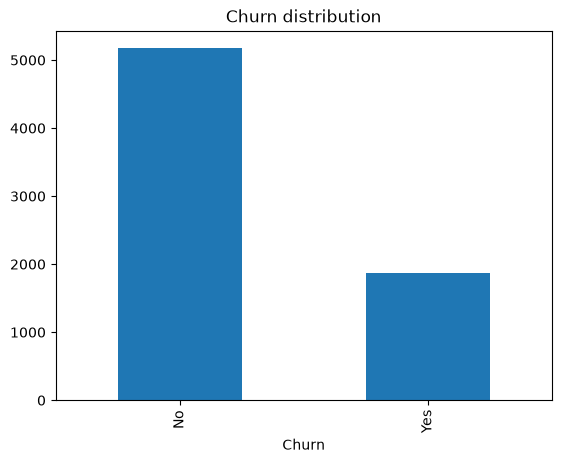

In [6]:
print(data["Churn"].value_counts(normalize=True).round(3))

data["Churn"].value_counts().plot(kind="bar", title="Churn distribution")
plt.show()

**26.5% of customers churn.** The classes are imbalanced: a model that predicts "nobody churns" would be 73.5% accurate while catching zero churners. That's why accuracy is the wrong metric here.

In [7]:
pd.crosstab(data["Contract"], data["Churn"], normalize="index").round(3)

Churn,No,Yes
Contract,,
Month-to-month,0.573,0.427
One year,0.887,0.113
Two year,0.972,0.028


Contract type is the strongest single signal: **month-to-month customers churn at 42.7%, two-year customers at 2.8%** (about 15× lower). Without a contract there's nothing stopping a customer from leaving.

In [8]:
pd.crosstab(data["PaymentMethod"], data["Churn"], normalize="index").round(3)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.833,0.167
Credit card (automatic),0.848,0.152
Electronic check,0.547,0.453
Mailed check,0.809,0.191


Electronic check payers churn at 45%, compared with 15–19% for automatic payment methods. To see whether payment method and contract type **reinforce each other**, look at churn rate for every combination. The mean of a 0/1 churn flag is the churn rate:

In [9]:
data["churn_flag"] = (data["Churn"] == "Yes").astype(int)
pd.pivot_table(data, values="churn_flag", index="PaymentMethod",
               columns="Contract", aggfunc="mean").round(3)

Contract,Month-to-month,One year,Two year
PaymentMethod,,,
Bank transfer (automatic),0.341,0.097,0.034
Credit card (automatic),0.328,0.103,0.022
Electronic check,0.537,0.184,0.077
Mailed check,0.316,0.068,0.008


**Month-to-month + electronic check churns at 53.7%**, higher than either factor alone (42.7% and 45.3%), while mailed check + two-year churns at 0.8%. The risks compound, so churn is concentrated in specific segments. Payment method may be a *proxy* for commitment rather than a cause: correlation isn't causation.

In [10]:
pd.crosstab(data["InternetService"], data["Churn"], normalize="index").round(3)

Churn,No,Yes
InternetService,,
DSL,0.810,0.190
Fiber optic,0.581,0.419
No,0.926,0.074


Fiber optic customers churn at 41.9%, compared with 19.0% for DSL. (This was first flagged by SHAP in section 8 and then confirmed here in the raw data.)

## 4. Feature preparation

In [11]:
y = data["churn_flag"]
X = data.drop(columns=["customerID", "Churn", "churn_flag"])
X.shape

(7043, 19)

- `churn_flag` and `Churn` are the answer, so they can't be features.
- `customerID` is a random identifier with no predictive meaning. Keeping it would let the model memorize individual customers.

In [12]:
X = pd.get_dummies(X, drop_first=True)
X.shape

(7043, 30)

Models need numbers, so the text columns are **one-hot encoded**: one 0/1 column per category. This avoids inventing a false order (e.g. "Credit card = 3 × Electronic check").

`drop_first=True` removes one column per category, because it's fully predictable from the others (the *dummy variable trap*). That redundancy makes logistic regression's weights unstable. Trees don't care, but it's the safe choice for both models.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Churn rate — train:", round(y_train.mean(), 3), "| test:", round(y_test.mean(), 3))

Train: (5634, 30) | Test: (1409, 30)
Churn rate — train: 0.265 | test: 0.265


- The **test set** stays untouched until evaluation, so it can stand in for customers the model has never seen.
- `stratify=y` keeps the same 26.5% churn rate in both sets.
- `random_state=42` makes the split reproducible.

## 5. Baseline: logistic regression

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)
y_pred = logreg.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[925 110]
 [162 212]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



The scaler is **fit on the training set only** and then applied to the test set. Fitting it on the test set would leak test-set information (its mean and spread) into the pipeline.

The baseline reaches about 81% accuracy but only **57% recall on churners**: it misses 162 of 374. High accuracy comes from the easy majority class. This is the bar the next model has to beat.

## 6. XGBoost

In [15]:
xgb = XGBClassifier(random_state=42, eval_metric="logloss")
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

[[899 136]
 [179 195]]
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1035
           1       0.59      0.52      0.55       374

    accuracy                           0.78      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



Trees split on thresholds, so XGBoost gets the **unscaled** features. With default settings it does *worse* than the baseline on recall (52% vs 57%). A more powerful model doesn't fix class imbalance by itself: it still favors the majority class.

`scale_pos_weight` tells XGBoost to count each churner more heavily. The standard value is the ratio of non-churners to churners **in the training set**.

In [16]:
weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", round(weight, 3))

xgb_balance = XGBClassifier(random_state=42, eval_metric="logloss", scale_pos_weight=weight)
xgb_balance.fit(X_train, y_train)
y_pred_bal = xgb_balance.predict(X_test)

print(confusion_matrix(y_test, y_pred_bal))
print(classification_report(y_test, y_pred_bal))

scale_pos_weight: 2.769
[[816 219]
 [123 251]]


              precision    recall  f1-score   support

           0       0.87      0.79      0.83      1035
           1       0.53      0.67      0.59       374

    accuracy                           0.76      1409
   macro avg       0.70      0.73      0.71      1409
weighted avg       0.78      0.76      0.77      1409



Recall rises and precision falls: the model now catches more churners at the cost of more false alarms. Accuracy drops, which is acceptable because accuracy isn't the goal.

*Fix note:* an earlier version of this analysis computed `weight` from `y_test`. That's a small data leakage (test labels influencing training). The two ratios are almost identical thanks to stratification, but the correct source is `y_train`.

## 7. Probabilities, ROC-AUC and choosing the threshold

In [17]:
y_proba = xgb_balance.predict_proba(X_test)[:, 1]
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))

ROC-AUC: 0.818


`predict()` applies a fixed 0.5 cutoff to these scores, but the cutoff is a business decision. **ROC-AUC** measures how well the model *ranks* customers regardless of cutoff: it's the chance a random churner gets a higher score than a random non-churner (0.5 = random, 1.0 = perfect).

To choose the cutoff, assign each mistake a cost (assumed here: a lost customer ₹5,000, a wasted offer ₹500) and compare thresholds:

In [18]:
COST_FN, COST_FP = 5000, 500

rows = []
for t in [0.01, 0.02, 0.03, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]:
    preds = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    rows.append({
        "threshold": t,
        "missed churners (FN)": fn,
        "false alarms (FP)": fp,
        "customers flagged %": round(100 * (tp + fp) / len(y_test), 1),
        "recall": round(tp / (tp + fn), 2),
        "precision": round(tp / (tp + fp), 2),
        "cost (₹)": fn * COST_FN + fp * COST_FP,
    })
sweep = pd.DataFrame(rows)
sweep

,threshold,missed churners (FN),false alarms (FP),customers flagged %,recall,precision,cost (₹)
0,0.01,7,756,79.7,0.98,0.33,413000
1,0.02,11,689,74.7,0.97,0.35,399500
2,0.03,15,640,70.9,0.96,0.36,395000
3,0.05,26,570,65.2,0.93,0.38,415000
4,0.10,40,483,58.0,0.89,0.41,441500
5,0.15,52,423,52.9,0.86,0.43,471500
6,0.20,62,374,48.7,0.83,0.45,497000
7,0.25,69,333,45.3,0.82,0.48,511500
8,0.30,73,302,42.8,0.80,0.50,516000
9,0.40,93,264,38.7,0.75,0.52,597000


Because a missed churner costs 10× a wasted offer, cost falls as the threshold drops and reaches its minimum at **0.03** (₹395,000). Below that it rises again as false alarms pile up. But 0.03 flags about **71% of all customers**, far more than a retention team could contact. The cost-optimal threshold isn't a usable one.

**Chosen threshold: 0.30.** It catches about 80% of churners and flags about 43% of customers. It's a judgment call between recall and workload; in practice it would be set together with the retention team's real capacity and the business's real costs.

In [19]:
THRESHOLD = 0.30
y_pred_final = (y_proba >= THRESHOLD).astype(int)


def summarize(name, y_hat):
    return {
        "model": name,
        "accuracy": round(accuracy_score(y_test, y_hat), 3),
        "precision (churn)": round(precision_score(y_test, y_hat), 3),
        "recall (churn)": round(recall_score(y_test, y_hat), 3),
        "missed churners": int(((y_test == 1) & (y_hat == 0)).sum()),
    }


pd.DataFrame([
    summarize("Logistic regression (0.5)", y_pred),
    summarize("XGBoost default (0.5)", y_pred_xgb),
    summarize("XGBoost + scale_pos_weight (0.5)", y_pred_bal),
    summarize(f"XGBoost + scale_pos_weight ({THRESHOLD})", y_pred_final),
])

,model,accuracy,precision (churn),recall (churn),missed churners
0,Logistic regression (0.5),0.807,0.658,0.567,162
1,XGBoost default (0.5),0.776,0.589,0.521,179
2,XGBoost + scale_pos_weight (0.5),0.757,0.534,0.671,123
3,XGBoost + scale_pos_weight (0.3),0.734,0.499,0.805,73


From the baseline to the final model, accuracy drops from 0.81 to 0.73 while missed churners fall from 162 to 73. For this problem that's the right trade.

## 8. Explaining the model with SHAP

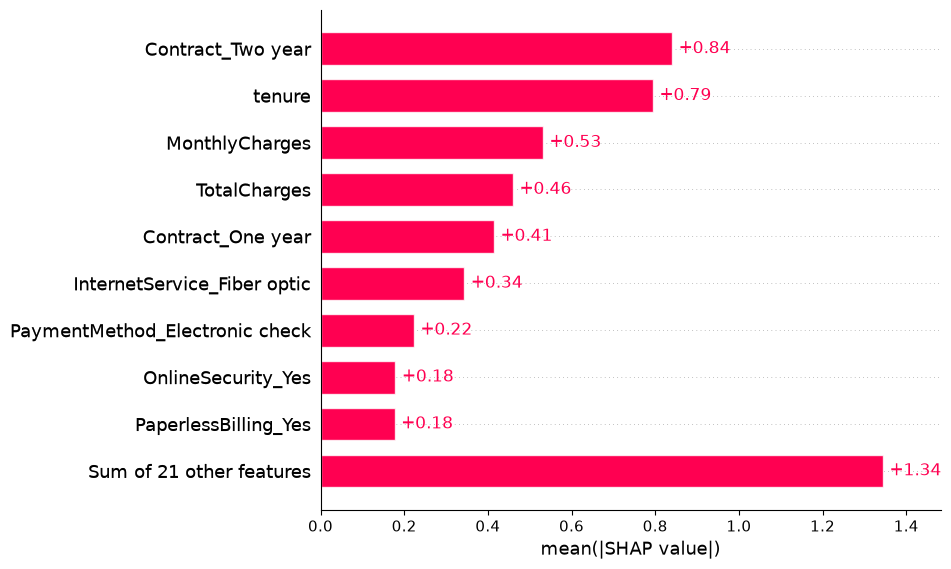

In [20]:
explainer = shap.TreeExplainer(xgb_balance)
shap_values = explainer(X_test)
shap.plots.bar(shap_values)

SHAP splits each prediction into a contribution per feature: starting from the model's average output, each feature pushes the score up (toward churn) or down (toward staying), and the contributions add up exactly to the prediction.

The top drivers are **contract type, tenure and monthly charges**, the same factors the EDA pointed to. There is no `Contract_Month-to-month` bar because `drop_first` removed that column: a month-to-month customer is encoded as One year = 0 and Two year = 0.

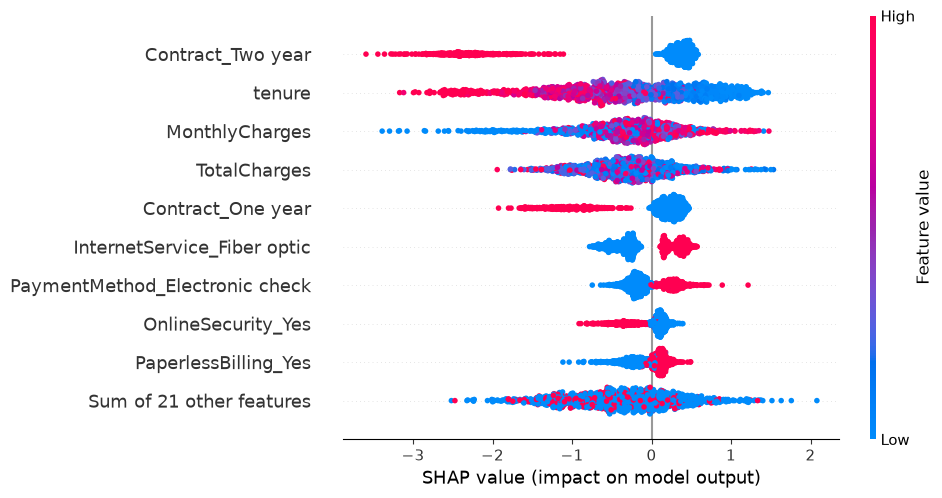

In [21]:
shap.plots.beeswarm(shap_values)

Each dot is one customer, and color is the feature's value (red = high / yes, blue = low / no). Dots to the right push toward churn.

- **Short tenure** (blue) pushes toward churn, and long tenure pulls strongly toward staying.
- A **two-year contract** (red) pulls strongly toward staying.
- **Fiber optic** and **electronic check** push toward churn, while **tech support** pulls toward staying.
- Rows with mixed colors (e.g. `MonthlyCharges`) mean the effect depends on other features. These are interactions a linear model can't capture.

`tenure` and `TotalCharges` are correlated (TotalCharges ≈ tenure × MonthlyCharges), so SHAP splits credit between them and `TotalCharges` is hard to interpret on its own.

### One customer

A check that SHAP values add up to the model's raw output (log-odds), and that the sigmoid turns that output back into the predicted score:

In [22]:
i = 1
margin = xgb_balance.predict(X_test.iloc[[i]], output_margin=True)[0]
shap_sum = shap_values.base_values[i] + shap_values.values[i].sum()
print("model output (log-odds):", round(float(margin), 4))
print("base value + SHAP values:", round(float(shap_sum), 4))
print("sigmoid:", round(float(1 / (1 + np.exp(-shap_sum))), 4), "| predict_proba:", round(float(y_proba[i]), 4))

model output (log-odds): 3.241
base value + SHAP values: 3.241
sigmoid: 0.9623 | predict_proba: 0.9623


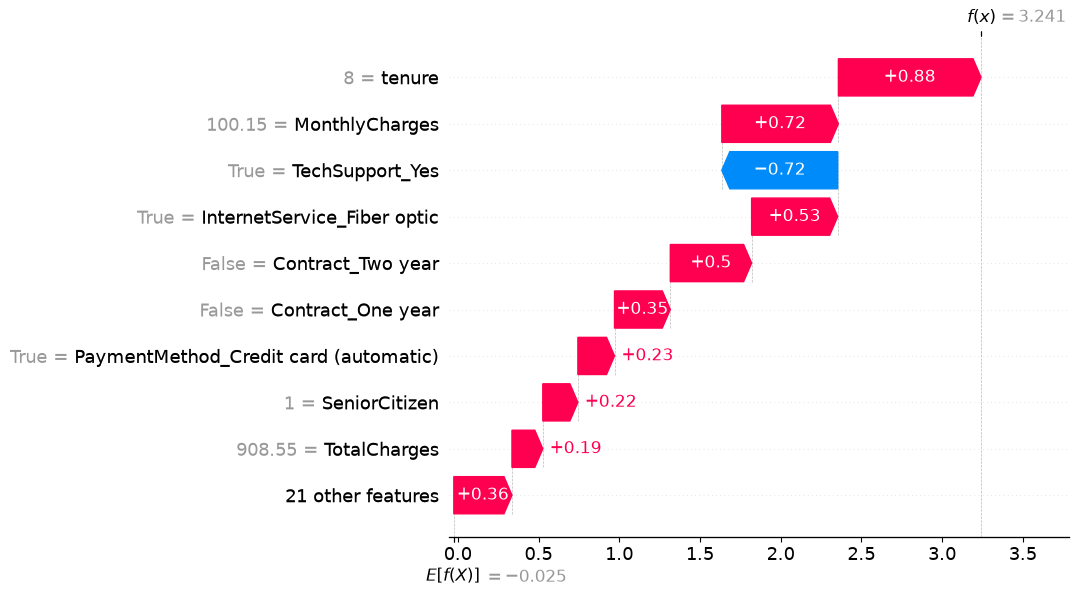

In [23]:
shap.plots.waterfall(shap_values[i])

This customer has a very high risk score: a senior citizen, 8 months in, on a month-to-month plan with fiber optic and a high monthly bill. Tech support is the main factor pulling the score down. A retention agent could act on that, e.g. by offering a discounted annual contract.

Two caveats:

In [24]:
data.loc[X_test.index[i], ["customerID", "tenure", "Contract", "Churn"]]

customerID        2754-SDJRD
tenure                     8
Contract      Month-to-month
Churn                     No
Name: 2280, dtype: object

- **This customer didn't churn.** A high score means "customers like this often leave", not "this person will leave". At a 0.30 threshold, false alarms like this one are an accepted, cheaper mistake.
- **Scores aren't calibrated probabilities.** `scale_pos_weight` effectively trains the model as if the classes were balanced, so its average output is around 50% while the real churn rate is 26.5%. The scores rank customers well (see ROC-AUC) but overstate probability. `CalibratedClassifierCV` would fix this if true probabilities were needed.
- SHAP explains **the model**, not cause and effect. Whether giving someone tech support *causes* them to stay would need an A/B test.

## 9. Save the model for the app

In [25]:
raw_cols = data.drop(columns=["customerID", "Churn", "churn_flag"]).columns
cat_cols = data[raw_cols].select_dtypes(exclude="number").columns
options = {c: sorted(data[c].unique()) for c in cat_cols}

artifacts = {
    "model": xgb_balance,
    "columns": list(X_train.columns),
    "threshold": THRESHOLD,
    "options": options,
}
joblib.dump(artifacts, "churn_model.joblib")

['churn_model.joblib']

The app receives **one customer at a time** as plain values ("Month-to-month", 8, ...) and has to rebuild exactly the 30 columns the model was trained on, with the same names and order. Getting this wrong is called **training-serving skew**, and it fails silently.

The obvious approach, `get_dummies(drop_first=True)`, breaks on a single row: every text column has only one category, so `drop_first` drops all of them. The app instead encodes without `drop_first` and then `reindex`es to the saved column list. The check below confirms that this reproduces the notebook exactly:

In [26]:
def preprocess(raw_df, columns):
    encoded = pd.get_dummies(raw_df)
    return encoded.reindex(columns=columns, fill_value=False)


idx = X_test.index[i]
raw = data.loc[[idx], raw_cols]
print("get_dummies(drop_first=True) on one row:", pd.get_dummies(raw, drop_first=True).shape)

row = preprocess(raw, artifacts["columns"])
assert list(row.columns) == list(X_test.columns)
assert (row.values == X_test.loc[[idx]].values).all()
print("Encoded row matches X_test:", row.shape)
print("App-style score:", round(float(xgb_balance.predict_proba(row)[0, 1]), 4),
      "| notebook score:", round(float(y_proba[i]), 4))

get_dummies(drop_first=True) on one row: (1, 4)
Encoded row matches X_test: (1, 30)
App-style score: 0.9623 | notebook score: 0.9623


## 10. Limitations and next steps

- **Single train/test split.** Cross-validation would give a more reliable estimate of performance.
- **Default hyperparameters** apart from `scale_pos_weight`. Tuning (e.g. `max_depth`, `learning_rate`, `n_estimators`) might improve results.
- **Assumed costs.** The ₹5,000 / ₹500 costs are placeholders. The right threshold depends on real costs and on how many customers the retention team can contact.
- **Uncalibrated scores**, and SHAP shows association, not causation (see section 8).
- **Static data.** In production, the model's inputs and performance would need monitoring, with retraining as customer behavior changes.

## 11. Lessons learned while building this

- **A clean null count can hide bad data.** `TotalCharges` had no nulls but was stored as text because of blank strings. The dtype showed the problem.
- **Too-good results are a red flag.** Accidentally training and testing on the same data produced ~99% accuracy. Real churn prediction isn't that easy, so a near-perfect score should be treated as a sign of leakage.
- **Small leaks count too.** `scale_pos_weight` was first computed from `y_test` and has been corrected to use `y_train`.
- **Code that works on a dataset can break on one row.** `drop_first` removed every column when encoding a single customer. The fix is to encode, reindex to the training columns, and test the app against known customers.
- **Environments matter.** Packages installed in one Python environment are invisible to a notebook kernel running in another. `sys.executable` shows which Python is actually running.